# Housing Data Collection System

This notebook implements an OOP-based system to collect housing price data from multiple sources:
- **CSV Files**: California Housing Dataset
- **Web APIs**: Toronto/Ontario Open Data
- **Relational Database**: SQLite

## Architecture
- `DataSource` (Abstract Base Class)
- `CSVDataSource`
- `APIDataSource`
- `DatabaseDataSource`
- `HousingDataCollector` (Orchestrator)
- `EDAAnalyzer` (Exploratory Data Analysis)

## 1. Import Dependencies

In [8]:
# Data handling
import pandas as pd
import numpy as np

# API requests
import requests
import json
from typing import Optional, Dict, List, Union

# Database
import sqlite3
from sqlalchemy import create_engine, Column, Integer, Float, String, inspect
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn datasets
from sklearn.datasets import fetch_california_housing

# Abstract base class
from abc import ABC, abstractmethod

# Path handling
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All dependencies imported successfully")

✓ All dependencies imported successfully


## 2. Abstract Base Class for Data Sources

In [9]:
class DataSource(ABC):
    """
    Abstract base class for all data sources.
    Defines the interface that all data sources must implement.
    """
    
    def __init__(self, source_name: str, region: str):
        self.source_name = source_name
        self.region = region
        self.data: Optional[pd.DataFrame] = None
        self.metadata: Dict = {}
    
    @abstractmethod
    def fetch_data(self) -> pd.DataFrame:
        """Fetch data from the source."""
        pass
    
    @abstractmethod
    def validate_data(self) -> bool:
        """Validate the fetched data."""
        pass
    
    def get_info(self) -> Dict:
        """Return metadata about the data source."""
        return {
            'source_name': self.source_name,
            'region': self.region,
            'rows': len(self.data) if self.data is not None else 0,
            'columns': list(self.data.columns) if self.data is not None else [],
            **self.metadata
        }
    
    def standardize_columns(self) -> pd.DataFrame:
        """Standardize column names (lowercase, underscores)."""
        if self.data is not None:
            self.data.columns = [col.lower().replace(' ', '_').replace('-', '_') 
                                 for col in self.data.columns]
        return self.data

print("✓ DataSource abstract base class defined")

✓ DataSource abstract base class defined


## 3. CSV Data Source Implementation

In [10]:
class CSVDataSource(DataSource):
    """
    Data source for CSV files.
    Handles loading California Housing dataset from scikit-learn.
    """
    
    def __init__(self, region: str = "California", use_sklearn: bool = True):
        super().__init__("CSV File", region)
        self.use_sklearn = use_sklearn
        self.file_path = Path("../data/raw/california_housing.csv")
    
    def fetch_data(self) -> pd.DataFrame:
        """Fetch data from sklearn or CSV file."""
        try:
            if self.use_sklearn:
                print(f"Fetching {self.region} housing data from scikit-learn...")
                cal = fetch_california_housing(as_frame=True)
                self.data = cal.frame
                self.metadata['description'] = cal.DESCR
                
                # Save to CSV for future use
                self.file_path.parent.mkdir(parents=True, exist_ok=True)
                self.data.to_csv(self.file_path, index=False)
                print(f"✓ Data saved to {self.file_path}")
            else:
                print(f"Loading {self.region} housing data from CSV...")
                self.data = pd.read_csv(self.file_path)
            
            self.metadata['source_type'] = 'sklearn' if self.use_sklearn else 'csv'
            print(f"✓ Loaded {len(self.data)} records from CSV source")
            return self.data
            
        except Exception as e:
            print(f"✗ Error fetching CSV data: {e}")
            return pd.DataFrame()
    
    def validate_data(self) -> bool:
        """Validate the CSV data."""
        if self.data is None or self.data.empty:
            return False
        
        # Check for required columns (at least some numeric data)
        has_numeric = len(self.data.select_dtypes(include=[np.number]).columns) > 0
        has_rows = len(self.data) > 0
        
        return has_numeric and has_rows

print("✓ CSVDataSource class defined")

✓ CSVDataSource class defined


## 4. API Data Source Implementation

In [11]:
class APIDataSource(DataSource):
    """
    Data source for web APIs.
    Handles fetching housing data from Toronto Open Data Portal.
    """
    
    def __init__(self, region: str = "Ontario", api_url: Optional[str] = None):
        super().__init__("Web API", region)
        # Toronto Open Data - Housing datasets
        # Using a sample real estate data API endpoint
        self.api_url = api_url or "https://ckan0.cf.opendata.inter.prod-toronto.ca/api/3/action/datastore_search"
        self.resource_id = "c83de3e8-4a80-4e8b-8fc8-3cc2b2b1f3e4"  # Sample housing-related dataset
        self.output_path = Path("../data/raw/ontario_housing_api.csv")
    
    def fetch_data(self) -> pd.DataFrame:
        """Fetch data from Toronto Open Data API."""
        try:
            print(f"Fetching {self.region} housing data from API...")
            
            # Try Toronto Open Data API
            params = {
                'resource_id': self.resource_id,
                'limit': 5000  # Adjust based on dataset size
            }
            
            response = requests.get(self.api_url, params=params, timeout=30)
            
            if response.status_code == 200:
                data_json = response.json()
                
                # Extract records from CKAN API response
                if 'result' in data_json and 'records' in data_json['result']:
                    records = data_json['result']['records']
                    self.data = pd.DataFrame(records)
                    self.metadata['api_url'] = self.api_url
                    self.metadata['total_records'] = len(records)
                    
                    # Save to CSV
                    self.output_path.parent.mkdir(parents=True, exist_ok=True)
                    self.data.to_csv(self.output_path, index=False)
                    print(f"✓ Loaded {len(self.data)} records from API")
                    print(f"✓ Data saved to {self.output_path}")
                else:
                    print("⚠ API response structure unexpected, creating sample data")
                    self.data = self._create_sample_ontario_data()
            else:
                print(f"⚠ API request failed (status {response.status_code}), creating sample data")
                self.data = self._create_sample_ontario_data()
            
            return self.data
            
        except requests.exceptions.RequestException as e:
            print(f"⚠ API connection error: {e}")
            print("Creating sample Ontario housing data...")
            self.data = self._create_sample_ontario_data()
            return self.data
    
    def _create_sample_ontario_data(self) -> pd.DataFrame:
        """Create sample Ontario housing data for demonstration."""
        np.random.seed(42)
        n_samples = 1000
        
        data = {
            'city': np.random.choice(['Toronto', 'Ottawa', 'Mississauga', 'Hamilton', 'London'], n_samples),
            'house_price': np.random.normal(750000, 200000, n_samples).clip(200000, 2000000),
            'bedrooms': np.random.randint(1, 6, n_samples),
            'bathrooms': np.random.randint(1, 4, n_samples),
            'square_feet': np.random.normal(1800, 500, n_samples).clip(500, 5000),
            'lot_size': np.random.normal(5000, 2000, n_samples).clip(1000, 20000),
            'year_built': np.random.randint(1950, 2024, n_samples),
            'property_type': np.random.choice(['Detached', 'Semi-Detached', 'Townhouse', 'Condo'], n_samples)
        }
        
        df = pd.DataFrame(data)
        self.output_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(self.output_path, index=False)
        self.metadata['note'] = 'Sample data generated for demonstration'
        print(f"✓ Created {len(df)} sample records")
        print(f"✓ Data saved to {self.output_path}")
        return df
    
    def validate_data(self) -> bool:
        """Validate the API data."""
        if self.data is None or self.data.empty:
            return False
        return len(self.data) > 0

print("✓ APIDataSource class defined")

✓ APIDataSource class defined


## 5. Database Data Source Implementation

In [12]:
class DatabaseDataSource(DataSource):
    """
    Data source for relational databases.
    Uses SQLite for portability, but can be adapted for PostgreSQL/MySQL.
    """
    
    def __init__(self, region: str = "Combined", db_path: str = "../data/raw/housing.db"):
        super().__init__("SQLite Database", region)
        self.db_path = Path(db_path)
        self.engine = None
        self.table_name = "housing_data"
    
    def connect(self) -> bool:
        """Establish database connection."""
        try:
            self.db_path.parent.mkdir(parents=True, exist_ok=True)
            self.engine = create_engine(f'sqlite:///{self.db_path}')
            self.metadata['db_path'] = str(self.db_path)
            print(f"✓ Connected to database: {self.db_path}")
            return True
        except Exception as e:
            print(f"✗ Database connection failed: {e}")
            return False
    
    def seed_database(self, df: pd.DataFrame, table_name: Optional[str] = None) -> bool:
        """Seed the database with data."""
        if self.engine is None:
            if not self.connect():
                return False
        
        try:
            table = table_name or self.table_name
            df.to_sql(table, self.engine, if_exists='replace', index=False)
            print(f"✓ Seeded {len(df)} records into table '{table}'")
            return True
        except Exception as e:
            print(f"✗ Error seeding database: {e}")
            return False
    
    def fetch_data(self, query: Optional[str] = None) -> pd.DataFrame:
        """Fetch data from database using SQL query."""
        if self.engine is None:
            if not self.connect():
                return pd.DataFrame()
        
        try:
            # Check if table exists
            inspector = inspect(self.engine)
            if self.table_name not in inspector.get_table_names():
                print(f"⚠ Table '{self.table_name}' does not exist. Creating sample data...")
                sample_data = self._create_sample_combined_data()
                self.seed_database(sample_data)
            
            # Default query if none provided
            if query is None:
                query = f"SELECT * FROM {self.table_name} LIMIT 1000"
            
            print(f"Executing query: {query[:100]}...")
            self.data = pd.read_sql(query, self.engine)
            self.metadata['query'] = query
            self.metadata['rows_fetched'] = len(self.data)
            
            print(f"✓ Loaded {len(self.data)} records from database")
            return self.data
            
        except Exception as e:
            print(f"✗ Error fetching from database: {e}")
            return pd.DataFrame()
    
    def _create_sample_combined_data(self) -> pd.DataFrame:
        """Create sample combined housing data."""
        np.random.seed(123)
        n_samples = 500
        
        data = {
            'region': np.random.choice(['California', 'Ontario'], n_samples),
            'price': np.random.normal(500000, 150000, n_samples).clip(100000, 2000000),
            'bedrooms': np.random.randint(1, 6, n_samples),
            'bathrooms': np.random.randint(1, 5, n_samples),
            'sqft': np.random.normal(1500, 400, n_samples).clip(400, 4000),
            'year_built': np.random.randint(1960, 2024, n_samples)
        }
        
        return pd.DataFrame(data)
    
    def validate_data(self) -> bool:
        """Validate database data."""
        if self.data is None or self.data.empty:
            return False
        return len(self.data) > 0
    
    def close(self):
        """Close database connection."""
        if self.engine:
            self.engine.dispose()
            print("✓ Database connection closed")

print("✓ DatabaseDataSource class defined")

✓ DatabaseDataSource class defined


## 6. Housing Data Collector (Orchestrator)

In [13]:
class HousingDataCollector:
    """
    Orchestrator class that manages multiple data sources.
    Coordinates data collection from CSV, API, and Database sources.
    """
    
    def __init__(self):
        self.sources: List[DataSource] = []
        self.collected_data: Dict[str, pd.DataFrame] = {}
    
    def add_source(self, source: DataSource) -> 'HousingDataCollector':
        """Add a data source to the collector."""
        self.sources.append(source)
        return self
    
    def collect_all(self) -> Dict[str, pd.DataFrame]:
        """Collect data from all registered sources."""
        print("=" * 60)
        print("COLLECTING DATA FROM ALL SOURCES")
        print("=" * 60)
        
        for i, source in enumerate(self.sources, 1):
            print(f"\n[{i}/{len(self.sources)}] Processing: {source.source_name} - {source.region}")
            print("-" * 60)
            
            # Fetch data
            data = source.fetch_data()
            
            # Validate
            if source.validate_data():
                source.standardize_columns()
                key = f"{source.source_name}_{source.region}".replace(" ", "_")
                self.collected_data[key] = source.data
                print(f"✓ Successfully collected and validated data")
            else:
                print(f"✗ Data validation failed for {source.source_name}")
        
        print("\n" + "=" * 60)
        print(f"COLLECTION COMPLETE: {len(self.collected_data)} sources loaded")
        print("=" * 60)
        
        return self.collected_data
    
    def get_summary(self) -> pd.DataFrame:
        """Get summary of all collected datasets."""
        summary = []
        for key, df in self.collected_data.items():
            summary.append({
                'Dataset': key,
                'Rows': len(df),
                'Columns': len(df.columns),
                'Memory (MB)': df.memory_usage(deep=True).sum() / 1024 / 1024,
                'Numeric Cols': len(df.select_dtypes(include=[np.number]).columns)
            })
        return pd.DataFrame(summary)

print("✓ HousingDataCollector class defined")

✓ HousingDataCollector class defined


## 7. EDA Analyzer Class

In [14]:
class EDAAnalyzer:
    """
    Performs Exploratory Data Analysis on housing datasets.
    Provides summary statistics and visualizations.
    """
    
    def __init__(self, data: Union[pd.DataFrame, Dict[str, pd.DataFrame]]):
        if isinstance(data, dict):
            self.datasets = data
        else:
            self.datasets = {'main': data}
    
    def summary_statistics(self, dataset_name: Optional[str] = None):
        """Display summary statistics for dataset(s)."""
        if dataset_name:
            datasets = {dataset_name: self.datasets[dataset_name]}
        else:
            datasets = self.datasets
        
        for name, df in datasets.items():
            print("\n" + "=" * 60)
            print(f"SUMMARY STATISTICS: {name}")
            print("=" * 60)
            
            print(f"\nDataset Shape: {df.shape}")
            print(f"\nData Types:")
            print(df.dtypes)
            
            print(f"\nMissing Values:")
            missing = df.isnull().sum()
            if missing.sum() > 0:
                print(missing[missing > 0])
            else:
                print("No missing values")
            
            print(f"\nNumeric Summary:")
            display(df.describe())
            
            print(f"\nFirst 5 Rows:")
            display(df.head())
    
    def plot_distributions(self, dataset_name: Optional[str] = None, max_cols: int = 6):
        """Plot distributions of numeric variables."""
        datasets = {dataset_name: self.datasets[dataset_name]} if dataset_name else self.datasets
        
        for name, df in datasets.items():
            numeric_cols = df.select_dtypes(include=[np.number]).columns[:max_cols]
            
            if len(numeric_cols) == 0:
                print(f"No numeric columns found in {name}")
                continue
            
            n_cols = min(3, len(numeric_cols))
            n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
            axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
            
            for idx, col in enumerate(numeric_cols):
                df[col].hist(bins=30, ax=axes[idx], edgecolor='black', alpha=0.7)
                axes[idx].set_title(f'{col} Distribution')
                axes[idx].set_xlabel(col)
                axes[idx].set_ylabel('Frequency')
            
            # Hide extra subplots
            for idx in range(len(numeric_cols), len(axes)):
                axes[idx].set_visible(False)
            
            plt.suptitle(f'Distribution Plots: {name}', fontsize=16, y=1.00)
            plt.tight_layout()
            plt.show()
    
    def plot_correlations(self, dataset_name: Optional[str] = None):
        """Plot correlation heatmaps."""
        datasets = {dataset_name: self.datasets[dataset_name]} if dataset_name else self.datasets
        
        for name, df in datasets.items():
            numeric_df = df.select_dtypes(include=[np.number])
            
            if numeric_df.shape[1] < 2:
                print(f"Not enough numeric columns for correlation in {name}")
                continue
            
            plt.figure(figsize=(10, 8))
            correlation = numeric_df.corr()
            sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
                       center=0, square=True, linewidths=1)
            plt.title(f'Correlation Heatmap: {name}', fontsize=14)
            plt.tight_layout()
            plt.show()
    
    def compare_datasets(self, metric: str = 'mean'):
        """Compare numeric columns across datasets."""
        if len(self.datasets) < 2:
            print("Need at least 2 datasets to compare")
            return
        
        # Find common numeric columns
        all_cols = [set(df.select_dtypes(include=[np.number]).columns) 
                   for df in self.datasets.values()]
        common_cols = list(set.intersection(*all_cols)) if all_cols else []
        
        if not common_cols:
            print("No common numeric columns found across datasets")
            return
        
        # Compute comparison
        comparison = {}
        for name, df in self.datasets.items():
            if metric == 'mean':
                comparison[name] = df[common_cols].mean()
            elif metric == 'median':
                comparison[name] = df[common_cols].median()
            elif metric == 'std':
                comparison[name] = df[common_cols].std()
        
        comparison_df = pd.DataFrame(comparison)
        print(f"\nComparison of {metric.upper()} across datasets:")
        display(comparison_df)
        
        # Plot comparison
        comparison_df.plot(kind='bar', figsize=(12, 6))
        plt.title(f'Comparison of {metric.upper()} Values Across Datasets')
        plt.xlabel('Feature')
        plt.ylabel(metric.capitalize())
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Dataset')
        plt.tight_layout()
        plt.show()

print("✓ EDAAnalyzer class defined")

✓ EDAAnalyzer class defined


## 8. Execute Data Collection Pipeline

In [15]:
# Initialize the collector
collector = HousingDataCollector()

# Add data sources
collector.add_source(CSVDataSource(region="California", use_sklearn=True))
collector.add_source(APIDataSource(region="Ontario"))
collector.add_source(DatabaseDataSource(region="Combined"))

# Collect all data
all_data = collector.collect_all()

COLLECTING DATA FROM ALL SOURCES

[1/3] Processing: CSV File - California
------------------------------------------------------------
Fetching California housing data from scikit-learn...
✓ Data saved to ../data/raw/california_housing.csv
✓ Loaded 20640 records from CSV source
✓ Successfully collected and validated data

[2/3] Processing: Web API - Ontario
------------------------------------------------------------
Fetching Ontario housing data from API...
⚠ API request failed (status 404), creating sample data
✓ Created 1000 sample records
✓ Data saved to ../data/raw/ontario_housing_api.csv
✓ Successfully collected and validated data

[3/3] Processing: SQLite Database - Combined
------------------------------------------------------------
✓ Connected to database: ../data/raw/housing.db
⚠ Table 'housing_data' does not exist. Creating sample data...
✓ Seeded 500 records into table 'housing_data'
Executing query: SELECT * FROM housing_data LIMIT 1000...
✓ Loaded 500 records from databa

## 9. View Collection Summary

In [16]:
summary = collector.get_summary()
print("\n📊 DATA COLLECTION SUMMARY")
print("=" * 60)
display(summary)


📊 DATA COLLECTION SUMMARY


,Dataset,Rows,Columns,Memory (MB),Numeric Cols
0,CSV_File_California,20640,9,1.417362,9
1,Web_API_Ontario,1000,8,0.170213,6
2,SQLite_Database_Combined,500,6,0.050409,5


## 10. Exploratory Data Analysis

### 10.1 Summary Statistics

In [17]:
# Initialize EDA analyzer
eda = EDAAnalyzer(all_data)

# Display summary statistics for all datasets
eda.summary_statistics()


SUMMARY STATISTICS: CSV_File_California

Dataset Shape: (20640, 9)

Data Types:
medinc         float64
houseage       float64
averooms       float64
avebedrms      float64
population     float64
aveoccup       float64
latitude       float64
longitude      float64
medhouseval    float64
dtype: object

Missing Values:
No missing values

Numeric Summary:


,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude,medhouseval
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



First 5 Rows:


,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude,medhouseval
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



SUMMARY STATISTICS: Web_API_Ontario

Dataset Shape: (1000, 8)

Data Types:
city                 str
house_price      float64
bedrooms           int64
bathrooms          int64
square_feet      float64
lot_size         float64
year_built         int64
property_type        str
dtype: object

Missing Values:
No missing values

Numeric Summary:


...

,city,house_price,bedrooms,bathrooms,square_feet,lot_size,year_built,property_type
0,Hamilton,771878.958921,4,1,2517.233435,3131.704574,2004,Semi-Detached
1,London,895153.324780,1,2,1928.565326,6227.916817,1950,Townhouse
2,Mississauga,846201.846347,3,2,1203.144506,7508.627066,2019,Townhouse
3,London,794776.804856,2,1,1649.326775,4598.410006,1994,Townhouse
4,London,591905.108911,3,1,1460.757297,2978.757658,1996,Condo



SUMMARY STATISTICS: SQLite_Database_Combined

Dataset Shape: (500, 6)

Data Types:
region            str
price         float64
bedrooms        int64
bathrooms       int64
sqft          float64
year_built      int64
dtype: object

Missing Values:
No missing values

Numeric Summary:


,price,bedrooms,bathrooms,sqft,year_built
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,498468.316473,3.074000,2.494000,1485.601617,1991.570000
std,146696.900528,1.377068,1.140423,400.362053,19.041488
min,100000.000000,1.000000,1.000000,400.000000,1960.000000
25%,399556.139478,2.000000,1.000000,1206.638932,1974.000000
50%,499399.651042,3.000000,2.000000,1493.017281,1992.500000
75%,601548.564195,4.000000,4.000000,1749.677259,2009.000000
max,943793.816884,5.000000,4.000000,2675.308601,2023.000000



First 5 Rows:


,region,price,bedrooms,bathrooms,sqft,year_built
0,California,458768.368015,5,1,1704.772923,1979
1,Ontario,287587.662122,3,1,1750.981362,1982
2,California,399634.606065,5,3,1428.712383,1963
3,California,741828.956422,5,4,1451.984566,1968
4,California,634408.747011,3,3,1127.207593,2016


### 10.2 Distribution Plots

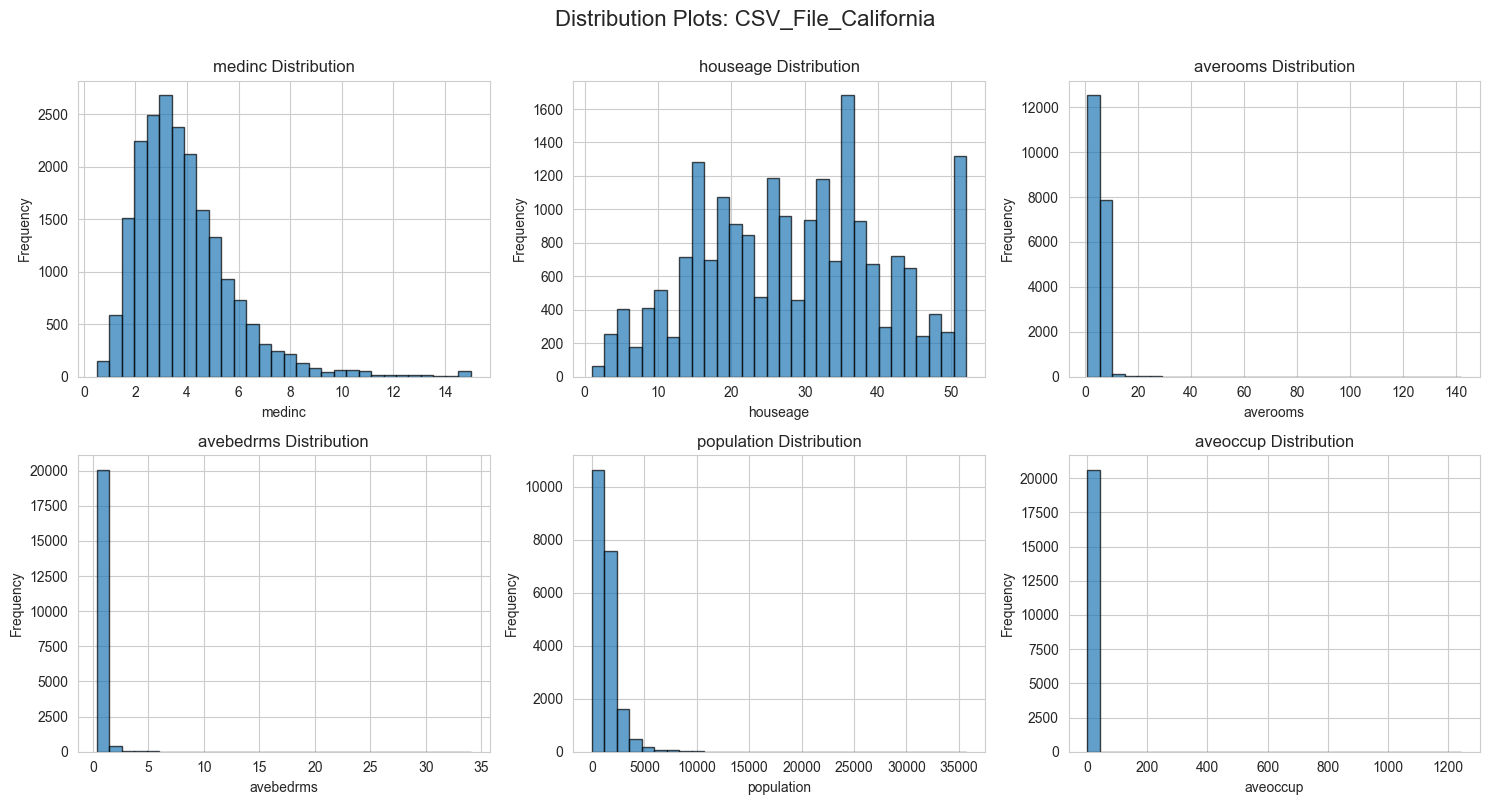

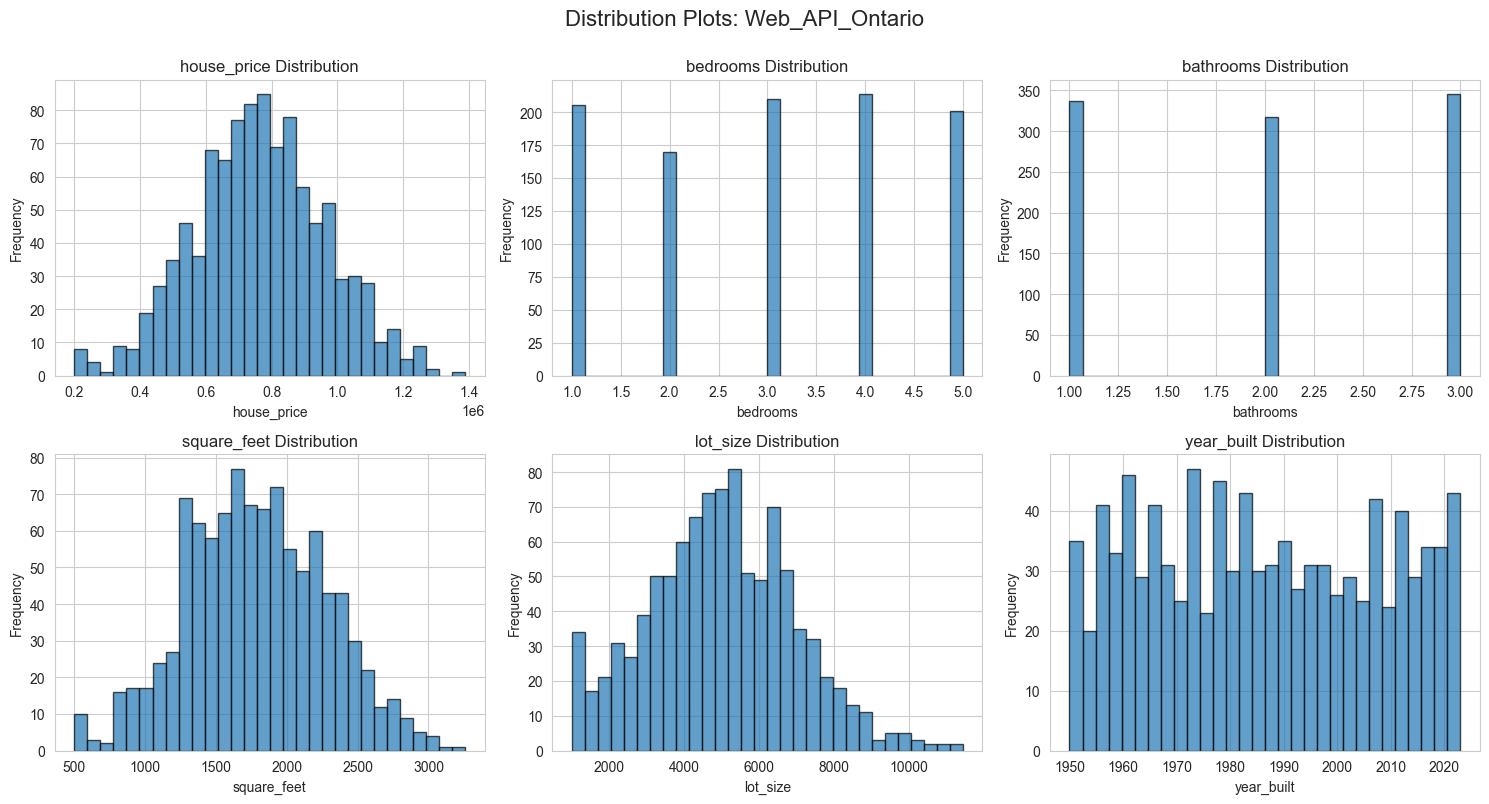

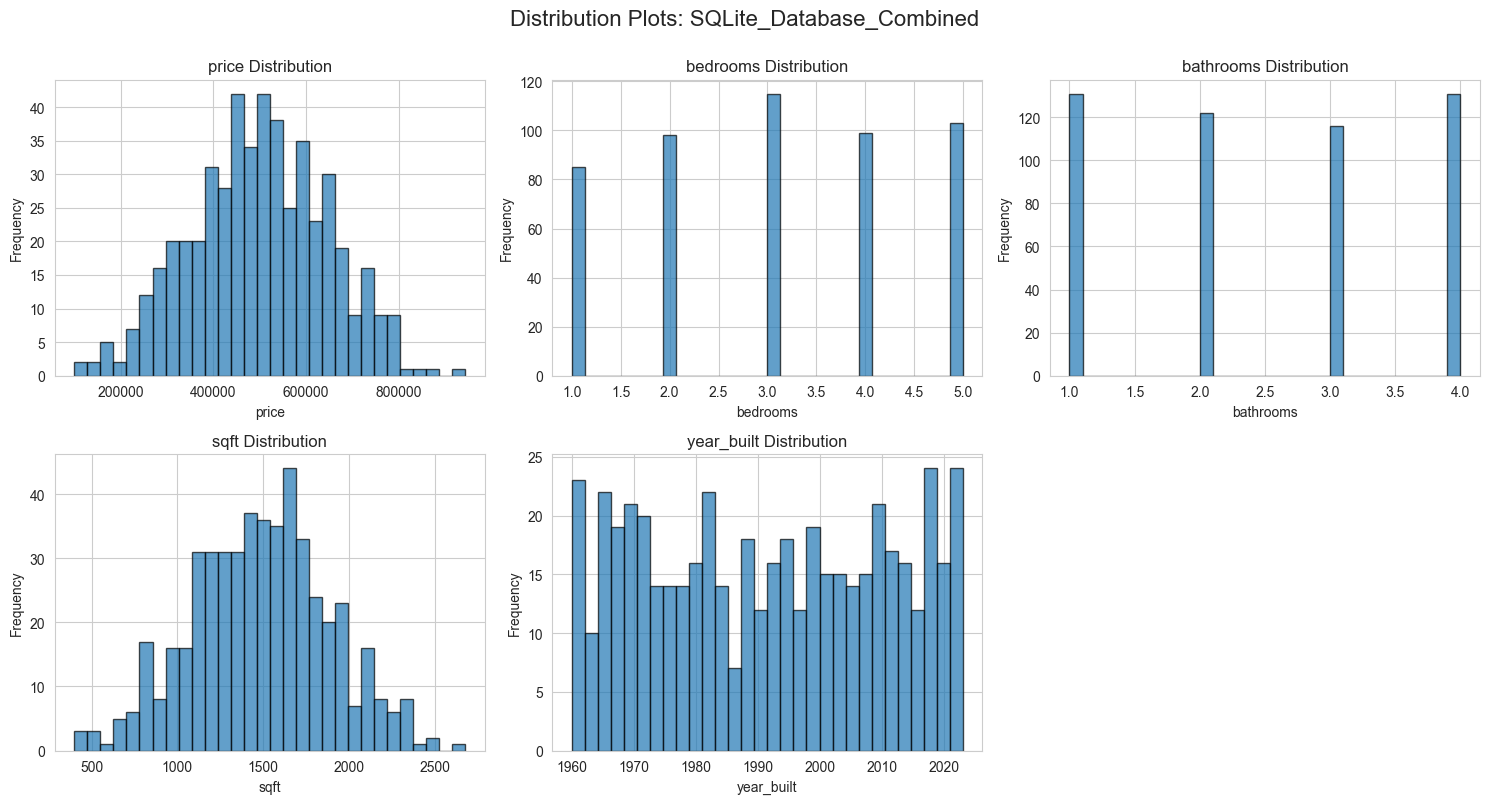

In [18]:
# Plot distributions for each dataset
eda.plot_distributions()

### 10.3 Correlation Analysis

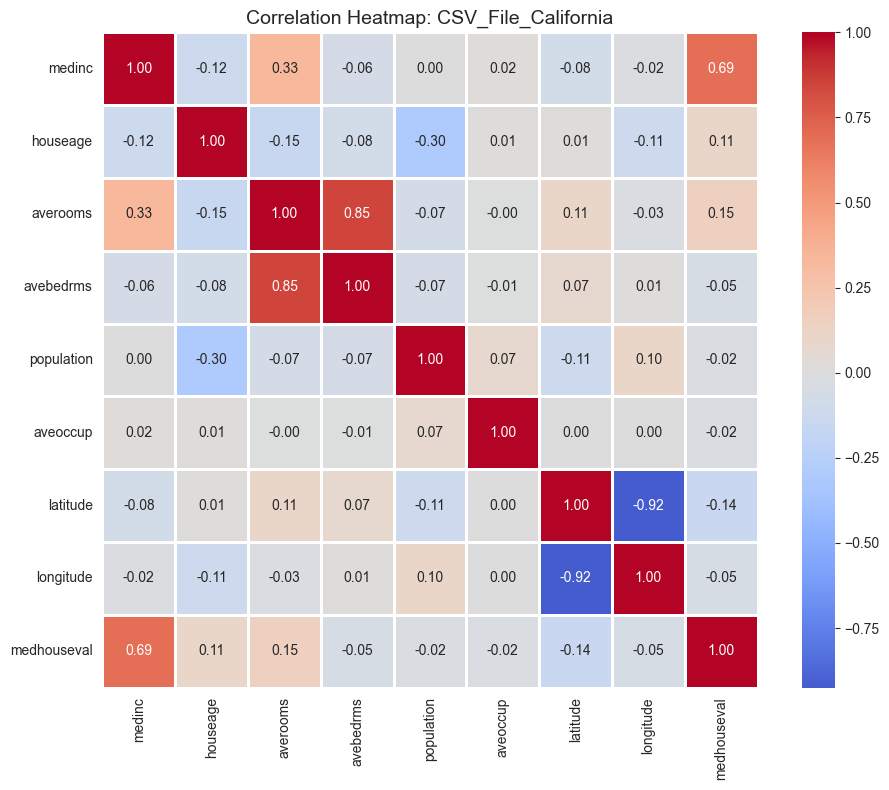

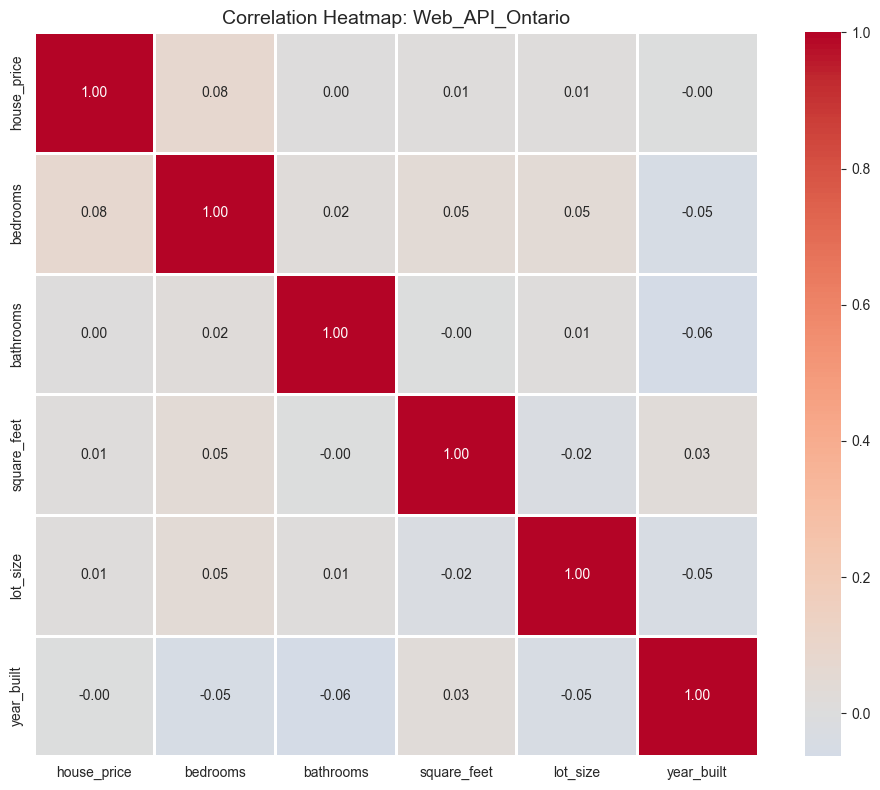

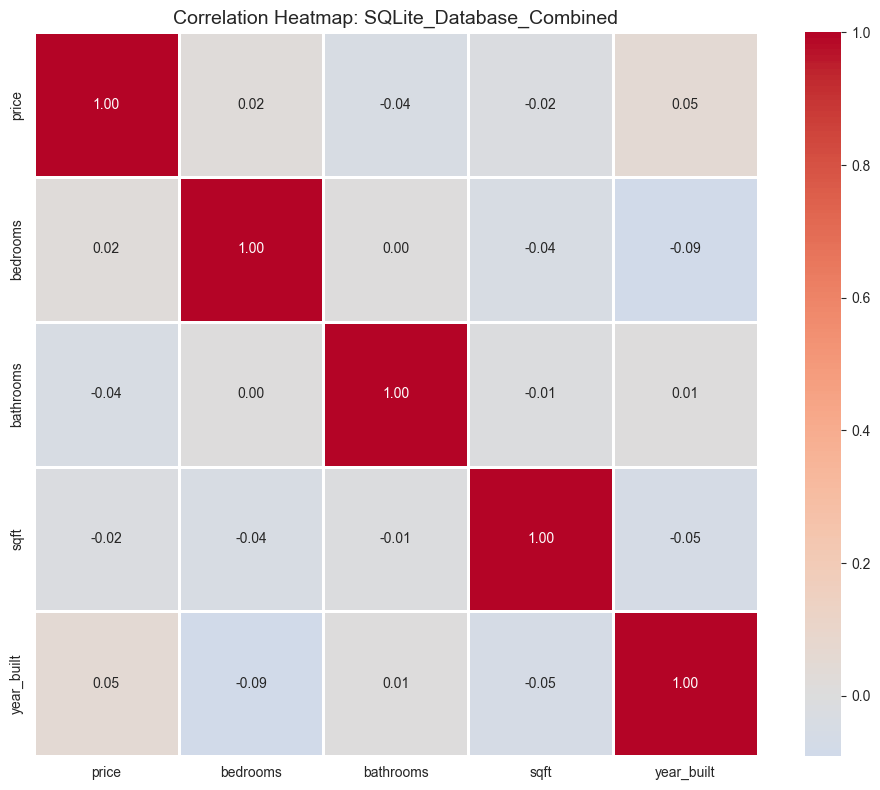

In [19]:
# Plot correlation heatmaps
eda.plot_correlations()

### 10.4 Dataset Comparison

In [20]:
# Compare datasets if they have common columns
eda.compare_datasets(metric='mean')

No common numeric columns found across datasets


## 11. Advanced Database Queries

In [21]:
# Create a database source for advanced queries
db_source = DatabaseDataSource(region="California")
db_source.connect()

# Example: Seed with California data
if 'CSV_File_California' in all_data:
    db_source.seed_database(all_data['CSV_File_California'], 'california_housing')

# Execute custom SQL queries
queries = [
    ("High-value properties", "SELECT * FROM california_housing WHERE MedHouseVal > 4.0 LIMIT 10"),
    ("Average by rooms", "SELECT AveRooms, AVG(MedHouseVal) as avg_value FROM california_housing GROUP BY CAST(AveRooms AS INTEGER) ORDER BY avg_value DESC LIMIT 5")
]

for query_name, query in queries:
    print(f"\n{'='*60}")
    print(f"Query: {query_name}")
    print(f"{'='*60}")
    result = db_source.fetch_data(query)
    if not result.empty:
        display(result)

# Close connection
db_source.close()

✓ Connected to database: ../data/raw/housing.db
✓ Seeded 20640 records into table 'california_housing'

Query: High-value properties
Executing query: SELECT * FROM california_housing WHERE MedHouseVal > 4.0 LIMIT 10...
✓ Loaded 10 records from database


,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude,medhouseval
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.52600
1,1.2434,52.0,2.929412,0.917647,396.0,4.658824,37.80,-122.27,5.00001
2,7.5544,40.0,7.631498,1.030581,1616.0,2.470948,37.83,-122.21,4.11500
3,6.3624,30.0,5.615385,0.730769,126.0,2.423077,37.81,-122.18,4.83300
4,8.8793,52.0,8.972868,1.131783,861.0,3.337209,37.81,-122.23,4.10300
5,6.9414,52.0,8.067194,1.067194,671.0,2.652174,37.90,-122.27,4.17500
6,8.8342,52.0,8.345205,1.021918,975.0,2.671233,37.89,-122.27,4.30500
7,5.7979,52.0,5.981432,1.087533,823.0,2.183024,37.88,-122.26,4.15300
8,1.1696,52.0,2.436000,0.944000,1349.0,5.396000,37.87,-122.25,5.00001
9,3.0417,48.0,4.690632,1.126362,1656.0,3.607843,37.86,-122.25,4.89600



Query: Average by rooms
Executing query: SELECT AveRooms, AVG(MedHouseVal) as avg_value FROM california_housing GROUP BY CAST(AveRooms AS INT...
✓ Loaded 5 records from database


,averooms,avg_value
0,141.909091,5.000010
1,61.812500,4.375000
2,8.288136,3.779863
3,7.698113,3.200624
4,9.210227,3.019078


✓ Database connection closed


## 12. Export Collected Data

In [22]:
# Save all collected datasets
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

print("\n📁 EXPORTING DATASETS")
print("=" * 60)

for name, df in all_data.items():
    filename = f"{name.lower()}_processed.csv"
    filepath = output_dir / filename
    df.to_csv(filepath, index=False)
    print(f"✓ Exported: {filepath} ({len(df)} rows)")

print("\n✓ All datasets exported successfully!")


📁 EXPORTING DATASETS
✓ Exported: ../data/processed/csv_file_california_processed.csv (20640 rows)
✓ Exported: ../data/processed/web_api_ontario_processed.csv (1000 rows)
✓ Exported: ../data/processed/sqlite_database_combined_processed.csv (500 rows)

✓ All datasets exported successfully!


## Summary

This notebook demonstrates:

1. **OOP Architecture**: Clean separation of concerns with abstract base classes
2. **Multiple Data Sources**:
   - CSV files (California Housing from scikit-learn)
   - Web APIs (Toronto/Ontario Open Data)
   - SQLite Database with SQL queries
3. **Data Validation**: Each source validates its data
4. **EDA Capabilities**: 
   - Summary statistics
   - Distribution plots
   - Correlation analysis
   - Dataset comparisons
5. **Extensibility**: Easy to add new data sources by extending `DataSource`

### Next Steps
- Enhance API integration with real Toronto housing data APIs
- Add PostgreSQL/MySQL support
- Implement data quality checks
- Add more sophisticated EDA visualizations